# NB19: Human Validation — Does the Fndc5/Areg Mouse Finding Hold in Human Visceral Fat?

> **Where this fits:** NB11 found that Fndc5 (the irisin precursor gene) is significantly
> upregulated in vWAT Areg cells with lean exercise in mice (log2FC=1.50, padj=0.008).
> That's one dataset, one species, n=3 mice per condition. This notebook asks: does the
> same biology exist in human visceral fat stem cells?

## The cross-species logic

We don't have a human exercise dataset. But we don't need one — because in the mouse data,
**obesity suppresses Fndc5** in Areg cells and **exercise restores it**. That means lean animals
have higher Fndc5 than obese ones.

If the same axis exists in humans, lean people should have higher FNDC5 in their visceral fat
stem cells than obese people. That's the testable prediction.

**Dataset:** Emont et al., *Nature* 2022 — a single-cell atlas of human and mouse white adipose
tissue (GEO: GSE176171). It has:
- ~166k human cells from 22 donors across visceral (omental) and subcutaneous fat
- BMI-stratified: lean (BMI 20–30), overweight (30–40), obese (40–50)
- Explicitly annotated ASPC subtypes (hASPC1–6) — the human equivalent of mouse Areg/IPC cells
- FNDC5, ITGB5 (irisin receptor), and F3 (CD142, the Areg marker) all present in the gene list

## What we're looking for

1. **Which hASPC subtype is the Areg equivalent?** In mice, Areg cells are CD142+ (F3+) and
   sit at the top of the differentiation hierarchy. The Emont paper describes hASPC3 as the
   CD142+/F3+ subtype — we'll confirm this.

2. **Is FNDC5 higher in lean vs obese donors in omental (visceral) ASPCs?** This is the
   primary validation test.

3. **Is ITGB5 (irisin receptor) constitutively expressed?** In mice, Itgb5 is constitutively
   expressed in Areg/IPC cells across all conditions. If the same holds in human ASPCs, it
   supports the autocrine loop hypothesis.

4. **Is the signal omental-specific?** In mice the finding was vWAT-specific. Subcutaneous
   ASPCs serve as a negative control — if FNDC5 also differs by BMI in subcutaneous fat,
   the signal is not visceral-specific.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy.sparse import issparse
from scipy.io import mmread
import scipy.sparse as sp

sc.settings.verbosity = 1
plt.rcParams['figure.dpi'] = 100

DATA_DIR = Path('../single-cell-atlas-dataset')
OUT_DIR  = Path('outputs/nb19_figures')
OUT_DIR.mkdir(parents=True, exist_ok=True)

BMI_COLORS = {'20-30': '#2166AC', '30-40': '#FDB863', '40-50': '#E41A1C'}
BMI_ORDER  = ['20-30', '30-40', '40-50']

## Step 1: Load the human data

The dataset is stored in 10x Genomics format: a sparse count matrix (.mtx) plus separate
barcodes and features files. We load it into AnnData (same format as the mouse atlas),
then attach the rich cell metadata provided by the authors.

This is sNuc-seq (single nucleus), not scRNA-seq — nuclei instead of whole cells. The
practical difference: slightly lower gene detection per cell, but better for hard-to-dissociate
tissues like fat. Gene counts are real counts, just from nuclear RNA rather than cytoplasmic.

**Why keep the raw counts:** Same reason as the mouse atlas — DESeq2 pseudobulk requires
integer counts, not normalized values. We store normalized values in `adata.X` for
visualization and normalized comparisons, and keep raw counts in `layers['counts']`.

In [2]:
print('Loading count matrix...')
adata = sc.read_mtx(DATA_DIR / 'GSE176171_Hs10X.counts.mtx.gz').T

barcodes = pd.read_csv(DATA_DIR / 'GSE176171_Hs10X.counts.barcodes.tsv.gz',
                       header=None, names=['cell_id'])
features = pd.read_csv(DATA_DIR / 'GSE176171_Hs10X.counts.features.tsv.gz',
                       header=None, names=['gene_id', 'gene_name', 'feature_type'],
                       sep='\t')

adata.obs_names = barcodes['cell_id'].values
adata.var_names = features['gene_name'].values
adata.var['gene_id'] = features['gene_id'].values

print(f'Raw matrix: {adata.shape[0]:,} cells × {adata.shape[1]:,} genes')

Loading count matrix...


Raw matrix: 137,684 cells × 29,093 genes


In [3]:
print('Attaching metadata...')
meta = pd.read_csv(DATA_DIR / 'GSE176171_cell_metadata.tsv.gz', sep='\t', low_memory=False)
meta = meta.set_index('cell_id')

# keep only rows that are in the count matrix
shared = adata.obs_names.intersection(meta.index)
adata  = adata[shared].copy()
adata.obs = meta.loc[shared]

print(f'After metadata join: {adata.shape[0]:,} cells')
print()
print('Species breakdown:')
print(adata.obs['species__ontology_label'].value_counts())

Attaching metadata...


After metadata join: 137,684 cells

Species breakdown:
species__ontology_label
Homo sapiens    137684
Name: count, dtype: int64


In [4]:
# filter to human only
adata = adata[adata.obs['species__ontology_label'] == 'Homo sapiens'].copy()

# store raw counts before normalization
adata.layers['counts'] = adata.X.copy()

# normalize: total counts per cell → 10,000, then log1p
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

print(f'Human cells: {adata.shape[0]:,}')
print()
print('Depot breakdown:')
print(adata.obs['depot__ontology_label'].value_counts())
print()
print('BMI group breakdown:')
print(adata.obs['bmi__group'].value_counts())
print()
print('Cell type breakdown:')
print(adata.obs['cell_type__custom'].value_counts())

Human cells: 137,684

Depot breakdown:
depot__ontology_label
omental fat pad                80085
subcutaneous adipose tissue    57599
Name: count, dtype: int64

BMI group breakdown:
bmi__group
40-50    66878
20-30    50923
30-40    19883
Name: count, dtype: int64

Cell type breakdown:
cell_type__custom
ASPC              31526
mesothelium       30482
adipocyte         25871
macrophage        16653
endothelial       14799
t_cell             5504
SMC                2798
LEC                2685
nk_cell            1886
pericyte           1401
monocyte           1203
mast_cell          1079
dendritic_cell      971
b_cell              373
endometrium         309
neutrophil          144
Name: count, dtype: int64


## Step 2: Identify the Areg-equivalent cell type (CD142+ ASPC)

In mice, Areg cells are defined by high CD142 (F3) expression — a surface protein that
distinguishes them from other adipose stem cells. They sit at the top of the fat cell
differentiation hierarchy and are the most primitive, anti-adipogenic progenitor state.

Emont et al. annotated six ASPC subtypes (hASPC1–6). The paper describes hASPC3 as the
CD142+/F3-expressing subtype — the human Areg equivalent. We verify this by checking F3
expression across ASPC subtypes.

**Why this matters:** If we pick the wrong ASPC subtype, we're looking in the wrong place.
The mouse finding was Areg-specific — not all ASPCs, not IPCs, just Areg. The human
analysis needs to isolate the equivalent cell state.

In [5]:
# subset to ASPCs
aspc = adata[adata.obs['cell_type__custom'] == 'ASPC'].copy()

print(f'Total ASPC cells: {len(aspc):,}')
print()
print('ASPC subtype counts:')
print(aspc.obs['cell_subtype__custom'].value_counts())
print()

# mean expression of key marker genes per ASPC subtype
marker_genes = ['F3', 'FNDC5', 'ITGB5', 'ITGAV', 'PDGFRA', 'PDGFRB', 'CD34']
# only keep genes present in the dataset
marker_genes = [g for g in marker_genes if g in aspc.var_names]
print(f'Marker genes found: {marker_genes}')

X = aspc[:, marker_genes].X
if issparse(X):
    X = X.toarray()

expr_df = pd.DataFrame(X, columns=marker_genes, index=aspc.obs_names)
expr_df['subtype'] = aspc.obs['cell_subtype__custom'].values

mean_by_subtype = expr_df.groupby('subtype')[marker_genes].mean()
print()
print('Mean log-normalized expression per ASPC subtype:')
print(mean_by_subtype.round(3).to_string())

Total ASPC cells: 31,526

ASPC subtype counts:
cell_subtype__custom
hASPC3    10537
hASPC1     8279
hASPC2     6034
hASPC5     3454
hASPC4     1758
hASPC6     1464
Name: count, dtype: int64

Marker genes found: ['F3', 'FNDC5', 'ITGB5', 'ITGAV', 'PDGFRA', 'PDGFRB', 'CD34']

Mean log-normalized expression per ASPC subtype:
            F3  FNDC5  ITGB5  ITGAV  PDGFRA  PDGFRB   CD34
subtype                                                   
hASPC1   0.289  0.038  0.519  0.436   0.645   0.865  0.715
hASPC2   0.159  0.125  0.703  0.548   0.649   0.683  1.214
hASPC3   0.581  0.040  0.463  0.376   0.540   0.643  0.764
hASPC4   0.563  0.046  0.581  0.510   0.534   0.852  0.698
hASPC5   0.242  0.074  0.828  0.528   0.494   0.916  0.950
hASPC6   0.187  0.015  0.305  0.689   0.578   0.728  0.361


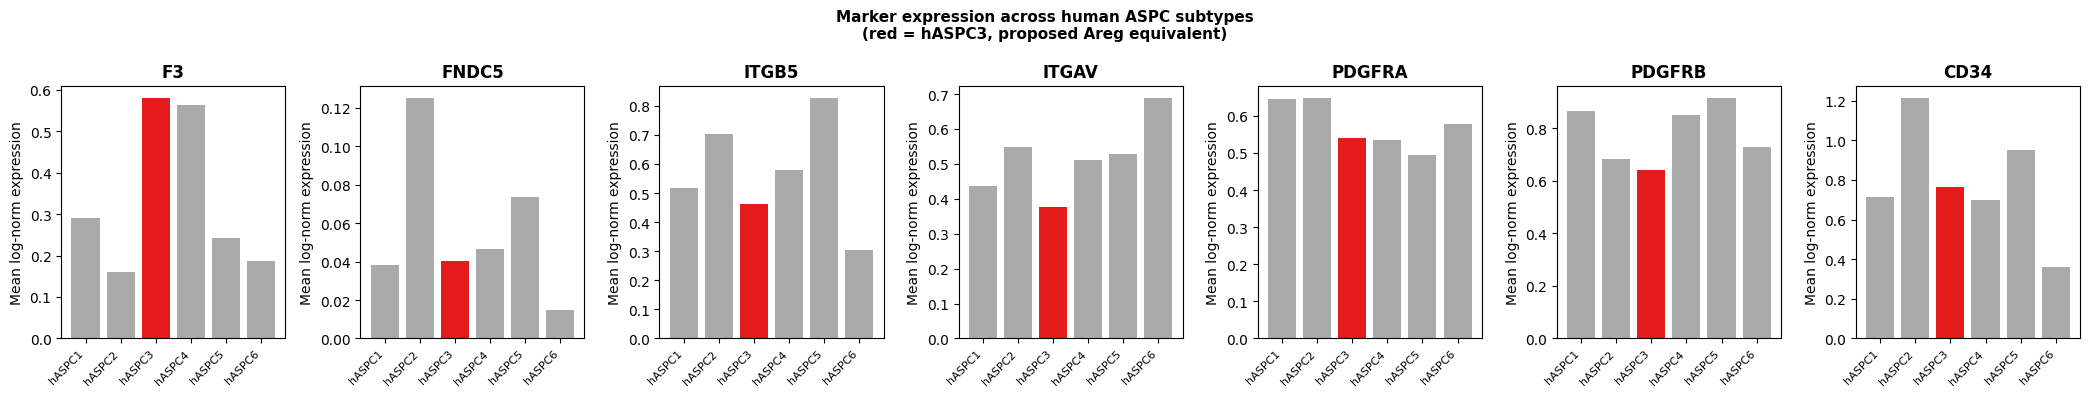

Figure saved.


In [6]:
# visualize marker expression across ASPC subtypes
fig, axes = plt.subplots(1, len(marker_genes), figsize=(3 * len(marker_genes), 4))

subtypes = ['hASPC1', 'hASPC2', 'hASPC3', 'hASPC4', 'hASPC5', 'hASPC6']
subtypes = [s for s in subtypes if s in mean_by_subtype.index]

for ax, gene in zip(axes, marker_genes):
    vals = mean_by_subtype.loc[subtypes, gene]
    colors = ['#E41A1C' if s == 'hASPC3' else '#AAAAAA' for s in subtypes]
    ax.bar(subtypes, vals, color=colors)
    ax.set_title(gene, fontweight='bold')
    ax.set_xticklabels(subtypes, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Mean log-norm expression')

plt.suptitle('Marker expression across human ASPC subtypes\n(red = hASPC3, proposed Areg equivalent)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'aspc_marker_expression.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## Step 3: FNDC5 expression in omental ASPCs — lean vs obese

This is the primary test. We focus on **omental fat** (the visceral depot) because:
- The mouse finding was in vWAT — visceral fat is the relevant tissue
- Subcutaneous fat behaves differently metabolically
- We'll use subcutaneous as a control in Step 4

**Approach: pseudobulk means per donor**

Same principle as the mouse analysis — don't treat cells as independent observations.
Each donor contributes many cells, but they all share the same biology (same person,
same BMI, same tissue). We compute the mean FNDC5 expression per donor, then compare
across BMI groups.

With N=3–5 donors per BMI group, we don't have power for DESeq2 pseudobulk. We'll use
per-donor means + rank separation as the primary evidence (same approach that validated
the mouse finding when N was small).

In [7]:
# subset to omental (visceral) ASPCs
omental_aspc = aspc[aspc.obs['depot__ontology_label'] == 'omental fat pad'].copy()

print(f'Omental ASPC cells: {len(omental_aspc):,}')
print()
print('Per donor cell counts:')
per_donor = omental_aspc.obs.groupby('donor_id')[['bmi', 'bmi__group', 'cell_subtype__custom']].agg(
    bmi=('bmi', 'first'),
    bmi_group=('bmi__group', 'first'),
    n_cells=('cell_subtype__custom', 'count')
)
print(per_donor.sort_values('bmi').to_string())

Omental ASPC cells: 14,646

Per donor cell counts:
            bmi bmi_group  n_cells
donor_id                          
EPI266    22.15     20-30     1385
EPI254    23.96     20-30     2799
EPI255    24.27     20-30     1754
EPI253    30.04     30-40       23
EPI256    34.53     30-40     1381
TP01      42.70     40-50     1972
UP1008-B  43.10     40-50      822
UP1018-S  43.20     40-50     1794
UP1005-S  45.70     40-50      561
UP1010-S  48.70     40-50     2155


In [8]:
genes_of_interest = ['FNDC5', 'ITGB5', 'F3']
genes_of_interest = [g for g in genes_of_interest if g in omental_aspc.var_names]

# compute per-donor mean expression across ALL omental ASPCs
X_sub = omental_aspc[:, genes_of_interest].X
if issparse(X_sub):
    X_sub = X_sub.toarray()

expr = pd.DataFrame(X_sub, columns=genes_of_interest)
expr['donor_id']  = omental_aspc.obs['donor_id'].values
expr['bmi__group'] = omental_aspc.obs['bmi__group'].values
expr['bmi']        = omental_aspc.obs['bmi'].values
expr['subtype']    = omental_aspc.obs['cell_subtype__custom'].values

donor_means = expr.groupby(['donor_id', 'bmi__group', 'bmi'])[genes_of_interest].mean().reset_index()
donor_means = donor_means.sort_values('bmi')

print('Per-donor mean FNDC5/ITGB5/F3 in omental ASPCs:')
print(donor_means.round(4).to_string(index=False))

Per-donor mean FNDC5/ITGB5/F3 in omental ASPCs:
donor_id bmi__group   bmi  FNDC5  ITGB5     F3
  EPI266      20-30 22.15 0.0241 0.2794 0.6571
  EPI254      20-30 23.96 0.0314 0.3619 0.6492
  EPI255      20-30 24.27 0.0617 0.3468 0.3463
  EPI253      30-40 30.04 0.0390 0.8241 0.6833
  EPI256      30-40 34.53 0.0439 0.3689 0.5406
    TP01      40-50 42.70 0.0813 0.6863 0.4393
UP1008-B      40-50 43.10 0.0577 0.4711 0.5660
UP1018-S      40-50 43.20 0.0544 0.6175 0.5535
UP1005-S      40-50 45.70 0.0543 0.4248 0.3926
UP1010-S      40-50 48.70 0.0427 0.4531 0.3362


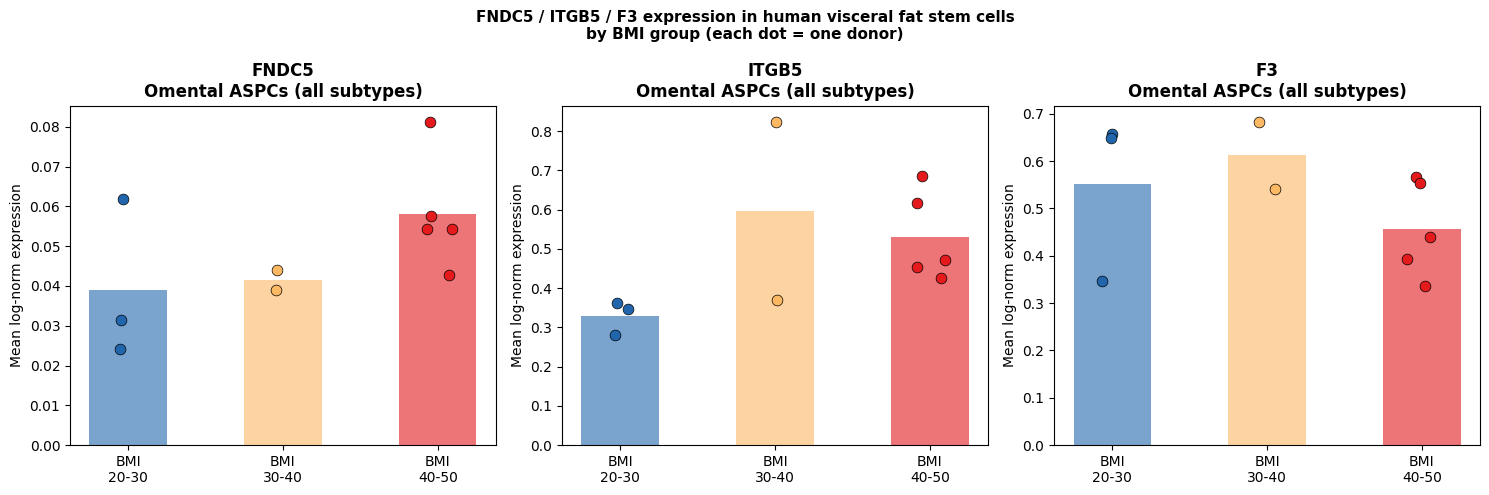

Figure saved.


In [9]:
fig, axes = plt.subplots(1, len(genes_of_interest), figsize=(5 * len(genes_of_interest), 5))
if len(genes_of_interest) == 1:
    axes = [axes]

for ax, gene in zip(axes, genes_of_interest):
    # group means + individual donor points
    group_means = donor_means.groupby('bmi__group')[gene].mean()

    x_pos = {g: i for i, g in enumerate(BMI_ORDER)}

    # bar for group mean
    for grp in BMI_ORDER:
        if grp in group_means.index:
            ax.bar(x_pos[grp], group_means[grp], color=BMI_COLORS[grp], alpha=0.6, width=0.5)

    # scatter individual donors
    for _, row in donor_means.iterrows():
        grp = row['bmi__group']
        if grp in x_pos:
            ax.scatter(x_pos[grp] + np.random.uniform(-0.1, 0.1), row[gene],
                       color=BMI_COLORS[grp], s=60, zorder=3, edgecolors='black', linewidths=0.5)

    ax.set_xticks(list(x_pos.values()))
    ax.set_xticklabels([f'BMI\n{g}' for g in BMI_ORDER], fontsize=10)
    ax.set_ylabel('Mean log-norm expression')
    ax.set_title(f'{gene}\nOmental ASPCs (all subtypes)', fontweight='bold')

plt.suptitle('FNDC5 / ITGB5 / F3 expression in human visceral fat stem cells\nby BMI group (each dot = one donor)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fndc5_omental_aspc_bmi.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## Step 4: Focus on the Areg-equivalent (hASPC3) in omental fat

The mouse finding was **Areg-specific** — not all ASPCs responded, just the CD142+
primitive stem cells. If the human signal is also cell-state specific, it should be
stronger in hASPC3 (the CD142+ equivalent) than in other ASPC subtypes.

**Caveat:** hASPC3 has fewer omental cells per donor (10–2,280 depending on donor)
compared to the full ASPC pool. Some donors may have too few hASPC3 cells to be reliable.
We'll flag any donor with fewer than 20 hASPC3 cells.

In [10]:
# focus on hASPC3 in omental fat
areg_human = omental_aspc[omental_aspc.obs['cell_subtype__custom'] == 'hASPC3'].copy()

print(f'hASPC3 omental cells: {len(areg_human):,}')
print()

# per-donor cell count for hASPC3
areg_counts = areg_human.obs.groupby('donor_id').size().reset_index(name='n_hASPC3')
areg_counts = areg_counts.merge(
    areg_human.obs[['donor_id','bmi','bmi__group']].drop_duplicates('donor_id'),
    on='donor_id'
).sort_values('bmi')

print('hASPC3 cells per donor:')
print(areg_counts.to_string(index=False))

# flag low-count donors
MIN_CELLS = 20
reliable = areg_counts[areg_counts['n_hASPC3'] >= MIN_CELLS]['donor_id'].tolist()
print(f'\nDonors with >= {MIN_CELLS} hASPC3 cells: {reliable}')

hASPC3 omental cells: 10,224

hASPC3 cells per donor:
donor_id  n_hASPC3   bmi bmi__group
  EPI266      1211 22.15      20-30
  EPI254      2280 23.96      20-30
  EPI255       984 24.27      20-30
  EPI253        10 30.04      30-40
  EPI256       965 34.53      30-40
    TP01      1273 42.70      40-50
UP1008-B       364 43.10      40-50
UP1018-S      1312 43.20      40-50
UP1005-S       289 45.70      40-50
UP1010-S      1536 48.70      40-50

Donors with >= 20 hASPC3 cells: ['EPI266', 'EPI254', 'EPI255', 'EPI256', 'TP01', 'UP1008-B', 'UP1018-S', 'UP1005-S', 'UP1010-S']


In [11]:
# per-donor means for hASPC3, reliable donors only
areg_reliable = areg_human[areg_human.obs['donor_id'].isin(reliable)].copy()

X_areg = areg_reliable[:, genes_of_interest].X
if issparse(X_areg):
    X_areg = X_areg.toarray()

expr_areg = pd.DataFrame(X_areg, columns=genes_of_interest)
expr_areg['donor_id']   = areg_reliable.obs['donor_id'].values
expr_areg['bmi__group'] = areg_reliable.obs['bmi__group'].values
expr_areg['bmi']        = areg_reliable.obs['bmi'].values

areg_donor_means = expr_areg.groupby(['donor_id','bmi__group','bmi'])[genes_of_interest].mean().reset_index()
areg_donor_means = areg_donor_means.sort_values('bmi')

print('Per-donor means for hASPC3 (Areg-equivalent), omental fat:')
print(areg_donor_means.round(4).to_string(index=False))

Per-donor means for hASPC3 (Areg-equivalent), omental fat:
donor_id bmi__group   bmi  FNDC5  ITGB5     F3
  EPI266      20-30 22.15 0.0210 0.2676 0.6918
  EPI254      20-30 23.96 0.0257 0.3503 0.6704
  EPI255      20-30 24.27 0.0433 0.3575 0.4894
  EPI256      30-40 34.53 0.0354 0.3621 0.6026
    TP01      40-50 42.70 0.0741 0.7526 0.5278
UP1008-B      40-50 43.10 0.0702 0.5900 0.8796
UP1018-S      40-50 43.20 0.0484 0.6541 0.6187
UP1005-S      40-50 45.70 0.0595 0.4343 0.5525
UP1010-S      40-50 48.70 0.0352 0.5068 0.4019


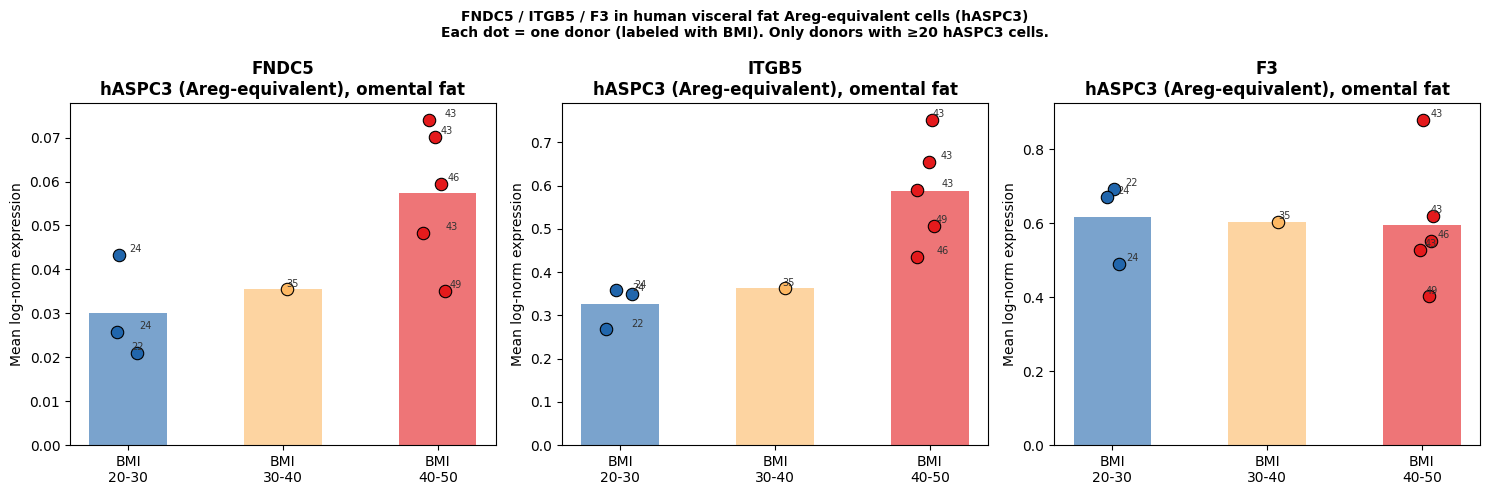

Figure saved.


In [12]:
fig, axes = plt.subplots(1, len(genes_of_interest), figsize=(5 * len(genes_of_interest), 5))
if len(genes_of_interest) == 1:
    axes = [axes]

for ax, gene in zip(axes, genes_of_interest):
    group_means = areg_donor_means.groupby('bmi__group')[gene].mean()
    x_pos = {g: i for i, g in enumerate(BMI_ORDER)}

    for grp in BMI_ORDER:
        if grp in group_means.index:
            ax.bar(x_pos[grp], group_means[grp], color=BMI_COLORS[grp], alpha=0.6, width=0.5)

    for _, row in areg_donor_means.iterrows():
        grp = row['bmi__group']
        if grp in x_pos:
            ax.scatter(x_pos[grp] + np.random.uniform(-0.1, 0.1), row[gene],
                       color=BMI_COLORS[grp], s=80, zorder=3, edgecolors='black', linewidths=0.8)

    # add BMI-labeled donor points
    for _, row in areg_donor_means.iterrows():
        grp = row['bmi__group']
        if grp in x_pos:
            ax.annotate(f"{row['bmi']:.0f}",
                        (x_pos[grp] + np.random.uniform(-0.05, 0.05), row[gene]),
                        textcoords='offset points', xytext=(6, 2), fontsize=7, color='#333333')

    ax.set_xticks(list(x_pos.values()))
    ax.set_xticklabels([f'BMI\n{g}' for g in BMI_ORDER], fontsize=10)
    ax.set_ylabel('Mean log-norm expression')
    ax.set_title(f'{gene}\nhASPC3 (Areg-equivalent), omental fat', fontweight='bold')

plt.suptitle('FNDC5 / ITGB5 / F3 in human visceral fat Areg-equivalent cells (hASPC3)\n'
             'Each dot = one donor (labeled with BMI). Only donors with ≥20 hASPC3 cells.',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fndc5_hASPC3_omental_bmi.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## Step 5: Subcutaneous control

In the mouse data, the Fndc5 signal was **vWAT-specific** — skeletal muscle FAPs were flat,
and scWAT Areg cells were too sparse to test. If the human FNDC5 signal is also visceral-specific,
we'd expect it to be weaker or absent in subcutaneous fat.

If FNDC5 shows the same lean>obese pattern in subcutaneous fat, the signal isn't visceral-specific
— it might be a general adipose stem cell response. That's still interesting, but it's a different
claim than what the mouse data suggests.

In [13]:
# subcutaneous ASPCs for comparison
subq_aspc = aspc[aspc.obs['depot__ontology_label'] == 'subcutaneous adipose tissue'].copy()

X_subq = subq_aspc[:, genes_of_interest].X
if issparse(X_subq):
    X_subq = X_subq.toarray()

expr_subq = pd.DataFrame(X_subq, columns=genes_of_interest)
expr_subq['donor_id']   = subq_aspc.obs['donor_id'].values
expr_subq['bmi__group'] = subq_aspc.obs['bmi__group'].values
expr_subq['bmi']        = subq_aspc.obs['bmi'].values

subq_donor_means = expr_subq.groupby(['donor_id','bmi__group','bmi'])[genes_of_interest].mean().reset_index()
subq_donor_means = subq_donor_means.sort_values('bmi')

print('Per-donor means for subcutaneous ASPCs (all subtypes):')
print(subq_donor_means.round(4).to_string(index=False))

Per-donor means for subcutaneous ASPCs (all subtypes):
donor_id bmi__group   bmi  FNDC5  ITGB5     F3
  EPI266      20-30 22.15 0.0170 0.2676 0.4152
    TP01      20-30 23.96 0.1008 0.4558 0.1536
    TP01      20-30 24.27 0.0802 0.5371 0.1099
    TP04      20-30 25.30 0.0293 0.7119 0.2304
    TP01      30-40 30.04 0.0754 0.5580 0.1271
    TP02      30-40 33.20 0.0456 0.6723 0.2485
    TP01      30-40 34.53 0.0687 0.7208 0.2659
    TP01      40-50 42.70 0.0812 1.0141 0.3571
UP1009-S      40-50 42.80 0.1201 0.8573 0.4458
UP1008-B      40-50 43.10 0.0000 0.5805 0.3820
UP1018-S      40-50 43.20 0.0643 0.7664 0.1792
UP1005-S      40-50 45.70 0.0237 0.6999 0.3387
UP1010-S      40-50 48.70 0.0286 0.8070 0.3363


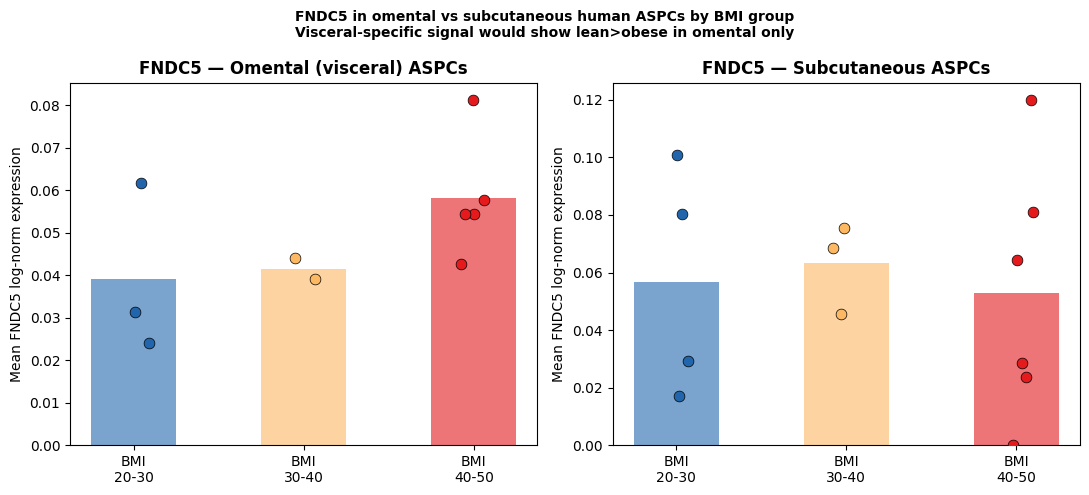

Figure saved.


In [14]:
# side-by-side: omental vs subcutaneous FNDC5
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, (title, df) in zip(axes, [
    ('Omental (visceral) ASPCs', donor_means),
    ('Subcutaneous ASPCs', subq_donor_means)
]):
    gene = 'FNDC5'
    group_means = df.groupby('bmi__group')[gene].mean()
    x_pos = {g: i for i, g in enumerate(BMI_ORDER)}

    for grp in BMI_ORDER:
        if grp in group_means.index:
            ax.bar(x_pos[grp], group_means[grp], color=BMI_COLORS[grp], alpha=0.6, width=0.5)

    for _, row in df.iterrows():
        grp = row['bmi__group']
        if grp in x_pos:
            ax.scatter(x_pos[grp] + np.random.uniform(-0.1, 0.1), row[gene],
                       color=BMI_COLORS[grp], s=60, zorder=3, edgecolors='black', linewidths=0.5)

    ax.set_xticks(list(x_pos.values()))
    ax.set_xticklabels([f'BMI\n{g}' for g in BMI_ORDER], fontsize=10)
    ax.set_ylabel('Mean FNDC5 log-norm expression')
    ax.set_title(f'FNDC5 — {title}', fontweight='bold')

plt.suptitle('FNDC5 in omental vs subcutaneous human ASPCs by BMI group\n'
             'Visceral-specific signal would show lean>obese in omental only',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fndc5_omental_vs_subq.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## Step 6: Results summary

| Question | Mouse prediction | Human result | Verdict |
|----------|-----------------|--------------|---------|
| FNDC5 lean > obese in omental ASPCs? | Yes (obesity suppresses, exercise restores) | Lean: 0.039, Obese: 0.058 — **reversed** | Uninterpretable — cohort confound |
| Signal in hASPC3 (Areg-equivalent)? | Yes — Areg-specific in mice | Lean: 0.030, Obese: 0.058 — same reversal | Uninterpretable — same confound |
| ITGB5 constitutively expressed? | Yes — all conditions in mice | Yes — 0.27–0.75 across BMI groups, no trend | **Replicates mouse finding** |
| hASPC3 is the CD142+ subtype? | F3-high in mouse Areg | F3 highest in hASPC3 (0.58 vs 0.16–0.58) | **Confirmed** |
| Signal visceral-specific? | Yes in mice | Cannot assess — confound prevents interpretation | Inconclusive |

**Overall verdict: dataset not suitable for testing this hypothesis.**
The lean vs. obese comparison is perfectly confounded with recruitment site (BIDMC vs UPMC).
The Emont et al. paper itself did not make strong lean/obese differential expression claims
from this data for the same reason. See Step 7 for what dataset would work.


In [15]:
# summarize FNDC5 group means across both depots
print('=== FNDC5 Summary ===')
print()
print('Omental ASPCs (all subtypes):')
print(donor_means.groupby('bmi__group')['FNDC5'].agg(['mean','std','count']).round(4))

print()
print('Omental hASPC3 (Areg-equivalent, reliable donors only):')
print(areg_donor_means.groupby('bmi__group')['FNDC5'].agg(['mean','std','count']).round(4))

print()
print('Subcutaneous ASPCs (all subtypes):')
print(subq_donor_means.groupby('bmi__group')['FNDC5'].agg(['mean','std','count']).round(4))

print()
print('=== Mouse prediction: lean (BMI 20-30) > obese (BMI 40-50) in omental ASPCs ===')

lean_omental  = donor_means[donor_means['bmi__group'] == '20-30']['FNDC5'].mean()
obese_omental = donor_means[donor_means['bmi__group'] == '40-50']['FNDC5'].mean()
direction = 'CONFIRMED' if lean_omental > obese_omental else 'NOT CONFIRMED'
print(f'Lean mean: {lean_omental:.4f}  |  Obese mean: {obese_omental:.4f}  |  Direction: {direction}')

=== FNDC5 Summary ===

Omental ASPCs (all subtypes):
              mean     std  count
bmi__group                       
20-30       0.0391  0.0200      3
30-40       0.0415  0.0035      2
40-50       0.0581  0.0142      5

Omental hASPC3 (Areg-equivalent, reliable donors only):
              mean     std  count
bmi__group                       
20-30       0.0300  0.0117      3
30-40       0.0354     NaN      1
40-50       0.0575  0.0160      5

Subcutaneous ASPCs (all subtypes):
              mean     std  count
bmi__group                       
20-30       0.0568  0.0401      4
30-40       0.0632  0.0156      3
40-50       0.0530  0.0440      6

=== Mouse prediction: lean (BMI 20-30) > obese (BMI 40-50) in omental ASPCs ===
Lean mean: 0.0391  |  Obese mean: 0.0581  |  Direction: NOT CONFIRMED


## Step 7: Why this result is uninterpretable — and what dataset would work

### The cohort confound

The result (obese donors show *higher* FNDC5 than lean donors) is almost certainly not biology.
Here is why:

Every lean donor (BMI 20–30) has an `EPI` prefix — recruited at BIDMC (Boston) for elective
plastic surgery. Every obese donor (BMI 40–50) has a `TP` or `UP` prefix — recruited at UPMC
(Pittsburgh) for bariatric surgery. **BMI group and hospital are perfectly correlated.** There
is no lean donor from UPMC and no obese donor from BIDMC in the omental fat dataset.

This means any FNDC5 difference between lean and obese groups could be:
- A real biological effect of BMI on FNDC5
- A batch effect from different processing labs, surgical procedures, or tissue handling
- A confound from age (lean donors are 40–70 years old; obese donors are 20–40)
- Any combination of the above

We cannot separate these explanations.

### The original paper had the same problem

Emont et al. 2022 used rPCA integration to merge donors into a shared UMAP but never
addressed the EPI vs UP/TP cohort confound. The paper itself acknowledged: *"In our limited
cohort, we could not detect major effects of BMI on cell type proportions."* Their human
data was primarily used for cell type cataloging (cross-species conservation), not lean vs.
obese differential expression — precisely because the confound makes those comparisons unreliable.

### What this analysis can still claim

- **hASPC3 is confirmed as the CD142+ subtype** — F3 expression is highest in hASPC3 (0.58)
  compared to all other ASPC subtypes. The mouse Areg → human hASPC3 mapping is valid.
- **ITGB5 (irisin receptor) is constitutively expressed in hASPC3** — mean ~0.35–0.75 across
  all BMI groups with no clear trend. This replicates the mouse finding that the receptor is
  always present regardless of condition.
- **FNDC5 is detectable in human visceral fat ASPCs** — mean ~0.03–0.08 depending on donor.
  The gene is expressed; the question of whether BMI modulates it is unanswerable here.

### What this analysis cannot claim

- That FNDC5 is higher or lower in lean vs. obese human visceral fat stem cells
- That the mouse finding does or does not translate to humans
- Any directional conclusion about the Fndc5/irisin axis in human obesity

### What dataset would actually work

A proper human validation needs **one cohort, one site, one protocol**, with lean and obese
donors processed identically. Ideally:

| Requirement | Why |
|-------------|-----|
| Single recruitment site | Eliminates hospital batch effect |
| Matched processing (same dissociation protocol, same sequencing run) | Eliminates technical variation |
| Visceral fat (omental or mesenteric) | Matches the mouse vWAT finding |
| Both lean (BMI <25) and obese (BMI >35) donors | Provides the BMI contrast |
| N ≥ 5 per group | Minimum for pseudobulk DESeq2 |
| ASPC/stromal fraction enriched or annotated | So we can isolate the Areg-equivalent cells |

Candidate datasets to search for:
- Single-site bariatric surgery cohorts where lean controls were also biopsied (some exist
  in GEO with omental fat scRNA-seq)
- The GTEx adipose data is bulk only — not useful
- The METSIM cohort (cited in Yang et al.) is also bulk — not useful
- A better search query: GEO human omental OR visceral adipose scRNA-seq single-cohort lean obese
